<a href="https://colab.research.google.com/github/Somya456/Image-Segmentation-for-Disaster-Resilience/blob/main/Model_Training_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import cv2

import tensorflow as tf
import tensorflow.keras.backend as K

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

import albumentations as A

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"
# Load Training Data
X_train = np.load(os.path.join(DATASET_PATH, "X_train.npy"))
Y_train = np.load(os.path.join(DATASET_PATH, "Y_train.npy"))

# Load Validation Data
X_val = np.load(os.path.join(DATASET_PATH, "X_val.npy"))
Y_val = np.load(os.path.join(DATASET_PATH, "Y_val.npy"))

# Load Testing Data
X_test = np.load(os.path.join(DATASET_PATH, "X_test.npy"))
Y_test = np.load(os.path.join(DATASET_PATH, "Y_test.npy"))

print("=" * 50)
print("Dataset Shapes")
print("=" * 50)

print(f"Training Images   : {X_train.shape}")
print(f"Training Masks    : {Y_train.shape}")

print(f"\nValidation Images : {X_val.shape}")
print(f"Validation Masks  : {Y_val.shape}")

print(f"\nTesting Images    : {X_test.shape}")
print(f"Testing Masks     : {Y_test.shape}")

Dataset Shapes
Training Images   : (2720, 256, 256, 3)
Training Masks    : (2720, 256, 256, 1)

Validation Images : (340, 256, 256, 3)
Validation Masks  : (340, 256, 256, 1)

Testing Images    : (341, 256, 256, 3)
Testing Masks     : (341, 256, 256, 1)


In [ ]:
print("=" * 50)
print("Data Types")
print("=" * 50)

print("X_train :", X_train.dtype)
print("Y_train :", Y_train.dtype)

print("X_val   :", X_val.dtype)
print("Y_val   :", Y_val.dtype)

print("X_test  :", X_test.dtype)
print("Y_test  :", Y_test.dtype)

Data Types
X_train : float32
Y_train : uint8
X_val   : float32
Y_val   : uint8
X_test  : float32
Y_test  : uint8


In [ ]:
print("=" * 50)
print("Pixel Range")
print("=" * 50)

print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

print("=" * 50)
print("Unique Mask Values")
print("=" * 50)

print(np.unique(Y_train))

Pixel Range
Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0
Unique Mask Values
[0 1]


In [ ]:
# Data Augmentation Pipeline
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=20, border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    )
])

In [ ]:
# Apply augmentation to one image-mask pair
def augment_image(image, mask):
    augmented = train_transform(image=image, mask=mask)

    image = augmented["image"]
    mask = augmented["mask"]

    # Ensure mask stays binary
    mask = (mask > 0).astype(np.uint8)

    return image, mask

In [ ]:
# ============================================
# TensorFlow Data Generator
# ============================================

def data_generator(images, masks, batch_size=8, augment=False):

    while True:

        indices = np.random.permutation(len(images))

        for start in range(0, len(images), batch_size):

            end = start + batch_size

            batch_indices = indices[start:end]

            batch_images = []
            batch_masks = []

            for idx in batch_indices:

                image = images[idx]
                mask = masks[idx]

                if augment:
                    image, mask = augment_image(image, mask)

                batch_images.append(image.astype(np.float32))
                batch_masks.append(mask.astype(np.float32))

            yield (
                np.array(batch_images),
                np.array(batch_masks)
            )

In [ ]:
BATCH_SIZE = 8

train_generator = data_generator(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    augment=True
)

val_generator = data_generator(
    X_val,
    Y_val,
    batch_size=BATCH_SIZE,
    augment=False
)

Image Batch Shape : (8, 256, 256, 3)
Mask Batch Shape  : (8, 256, 256, 1)


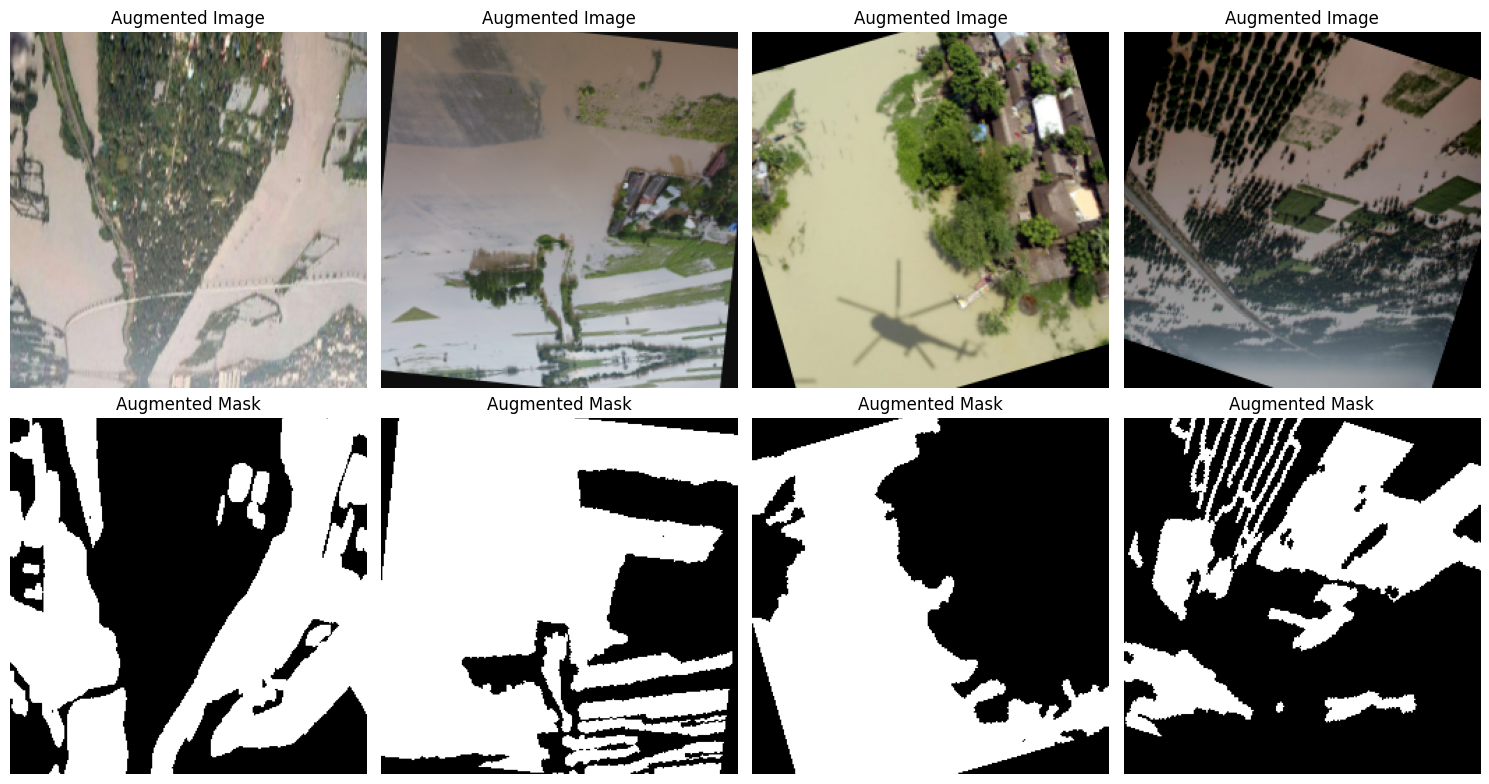

Training Steps : 340
Validation Steps : 42


In [ ]:
images, masks = next(train_generator)

print("Image Batch Shape :", images.shape)
print("Mask Batch Shape  :", masks.shape)

plt.figure(figsize=(15, 8))

for i in range(4):

    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title("Augmented Image")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(masks[i].squeeze(), cmap="gray")
    plt.title("Augmented Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

train_steps = len(X_train) // BATCH_SIZE

val_steps = len(X_val) // BATCH_SIZE

print("Training Steps :", train_steps)
print("Validation Steps :", val_steps)

In [ ]:
# ============================================
# Convert Masks to Float32
# ============================================

Y_train = Y_train.astype(np.float32)
Y_val = Y_val.astype(np.float32)
Y_test = Y_test.astype(np.float32)

print(Y_train.dtype)
print(Y_val.dtype)
print(Y_test.dtype)

# ============================================
# Dice Coefficient
# ============================================

def dice_coefficient(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)

    return (
        2.0 * intersection + 1.0
    ) / (
        K.sum(y_true) +
        K.sum(y_pred) +
        1.0
    )

float32
float32
float32


In [ ]:
# ============================================
# Dice Loss
# ============================================

def dice_loss(y_true, y_pred):

    return 1.0 - dice_coefficient(y_true, y_pred)

In [ ]:
# ============================================
# IoU Score
# ============================================

def iou_score(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)

    union = (
        K.sum(y_true)
        +
        K.sum(y_pred)
        -
        intersection
    )

    return (
        intersection + 1.0
    ) / (
        union + 1.0
    )

In [ ]:
# ============================================
# BCE + Dice Loss
# ============================================

bce = tf.keras.losses.BinaryCrossentropy()

def combined_loss(y_true, y_pred):

    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [ ]:
# ============================================
# Basic CNN Segmentation Model
# ============================================

def build_basic_cnn(input_shape=(256,256,3)):

    inputs = tf.keras.Input(shape=input_shape)

    # Encoder

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(inputs)

    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        128,
        3,
        activation="relu",
        padding="same"
    )(x)

    # Decoder

    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(x)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs,
        outputs,
        name="Basic_CNN"
    )

    return model

In [ ]:
cnn_model = build_basic_cnn()

cnn_model.summary()

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(

    optimizer=Adam(learning_rate=1e-3),

    loss=combined_loss,

    metrics=[
        "accuracy",
        dice_coefficient,
        iou_score
    ]
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(

    filepath=os.path.join(
        DATASET_PATH,
        "basic_cnn_best.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=4,

    min_lr=1e-6,

    verbose=1
)

In [ ]:
EPOCHS = 25

history_cnn = cnn_model.fit(

    train_generator,

    steps_per_epoch=train_steps,

    validation_data=val_generator,

    validation_steps=val_steps,

    epochs=EPOCHS,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/25
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7424 - dice_coefficient: 0.6128 - iou_score: 0.4502 - loss: 0.9091
Epoch 1: val_loss improved from None to 0.66377, saving model to /content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3/basic_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3/basic_cnn_best.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.7909 - dice_coefficient: 0.6638 - iou_score: 0.5032 - loss: 0.8014 - val_accuracy: 0.8232 - val_dice_coefficient: 0.7339 - val_iou_score: 0.5821 - val_loss: 0.6638 - learning_rate: 0.0010
Epoch 2/25
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8267 - dice_coefficient: 0.7174 - iou_score: 0.5627 - loss: 0.6857
Epoch 2: val_loss improved from 0.66377 to 0.64570, saving model to /content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3/basic_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task

In [ ]:
cnn_model.save(

    os.path.join(
        DATASET_PATH,
        "basic_cnn_final.keras"
    )
)

print("Basic CNN saved successfully.")

Basic CNN saved successfully.


In [ ]:
results = cnn_model.evaluate(
    X_test,
    Y_test,
    verbose=1,
    return_dict=True
)

print("\nTest Results")
print("-" * 40)

for key, value in results.items():
    print(f"{key:<20}: {value:.4f}")

cnn_metrics = {
    "Accuracy": 0.8928,
    "Dice": 0.8356,
    "IoU": 0.7178,
    "Loss": 0.4411
}

print(cnn_metrics)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8928 - dice_coefficient: 0.8356 - iou_score: 0.7178 - loss: 0.4411

Test Results
----------------------------------------
accuracy            : 0.8928
dice_coefficient    : 0.8356
iou_score           : 0.7178
loss                : 0.4411
{'Accuracy': 0.8928, 'Dice': 0.8356, 'IoU': 0.7178, 'Loss': 0.4411}


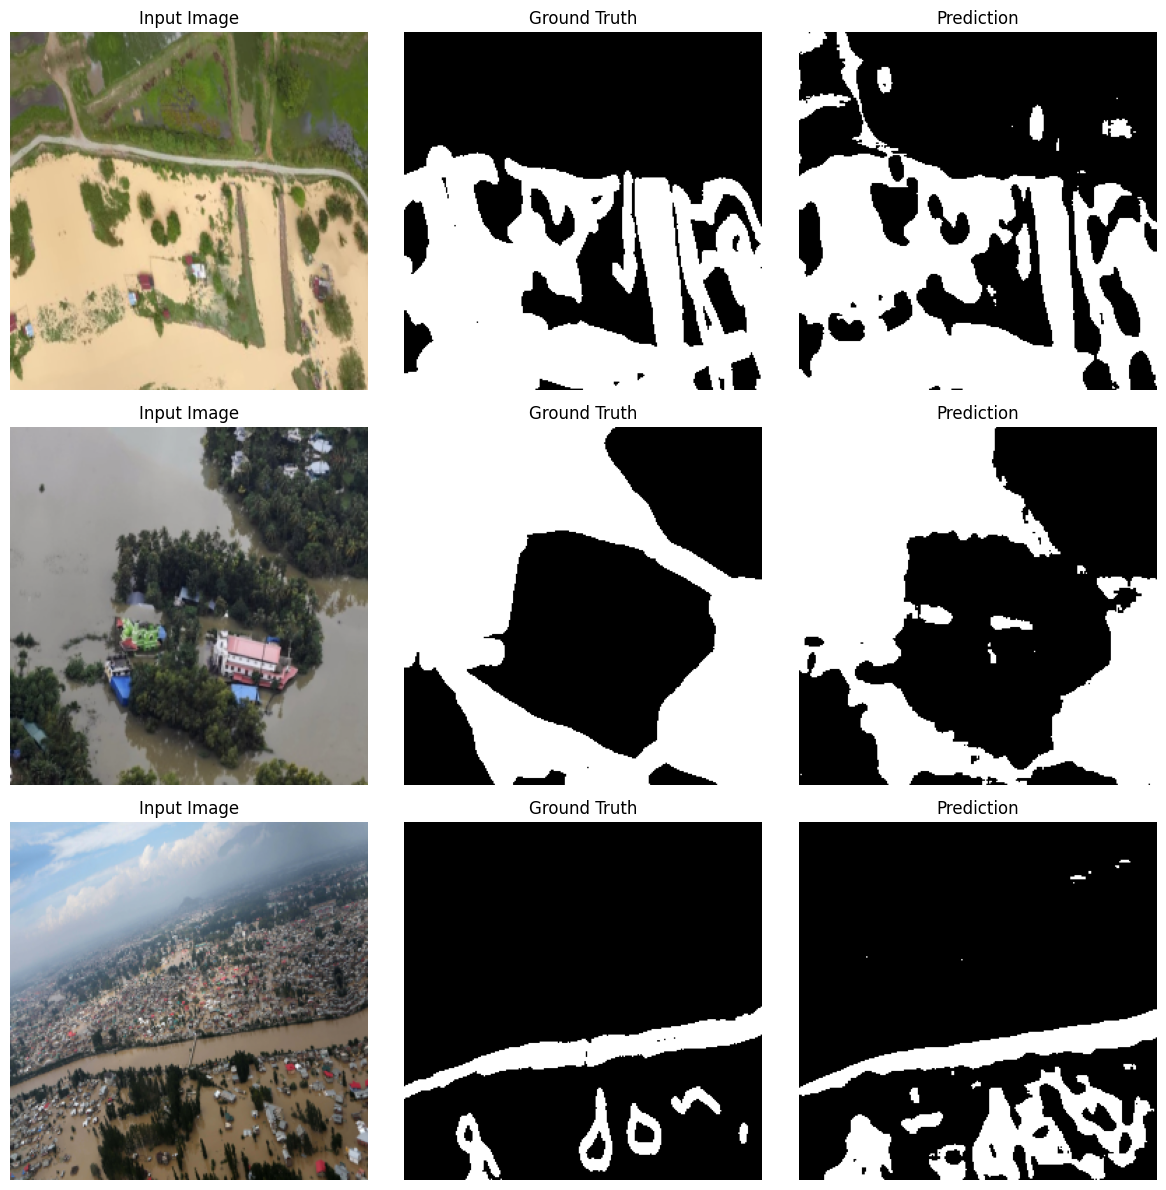

In [ ]:
num_samples = 3

indices = np.random.choice(
    len(X_test),
    num_samples,
    replace=False
)

plt.figure(figsize=(12,12))

for i, idx in enumerate(indices):

    image = X_test[idx]

    true_mask = Y_test[idx]

    pred = cnn_model.predict(

        np.expand_dims(image,0),

        verbose=0
    )[0]

    pred = (pred > 0.5).astype(np.uint8)

    plt.subplot(num_samples,3,3*i+1)

    plt.imshow(image)

    plt.title("Input Image")

    plt.axis("off")

    plt.subplot(num_samples,3,3*i+2)

    plt.imshow(
        true_mask.squeeze(),
        cmap="gray"
    )

    plt.title("Ground Truth")

    plt.axis("off")

    plt.subplot(num_samples,3,3*i+3)

    plt.imshow(
        pred.squeeze(),
        cmap="gray"
    )

    plt.title("Prediction")

    plt.axis("off")

plt.tight_layout()

plt.show()